# Concentration Gradient in a Catalyst Particle


When a reaction occurs inside a porous particle, the reactant concentration may be lower in the interior than at the surface. The profile depends on kinetics, internal diffusion, and external mass transfer from the fluid.

The example uses a first-order spherical model. The plot compares several scenarios to show which resistance dominates.


Scenario summary
Fast transfer: phi=0.40, eta=0.99, C_surface/C_bulk=1.00
Low internal diffusion: phi=0.90, eta=0.95, C_surface/C_bulk=1.00
Slow external film: phi=0.40, eta=0.99, C_surface/C_bulk=0.98
Fast kinetics: phi=0.76, eta=0.96, C_surface/C_bulk=0.99


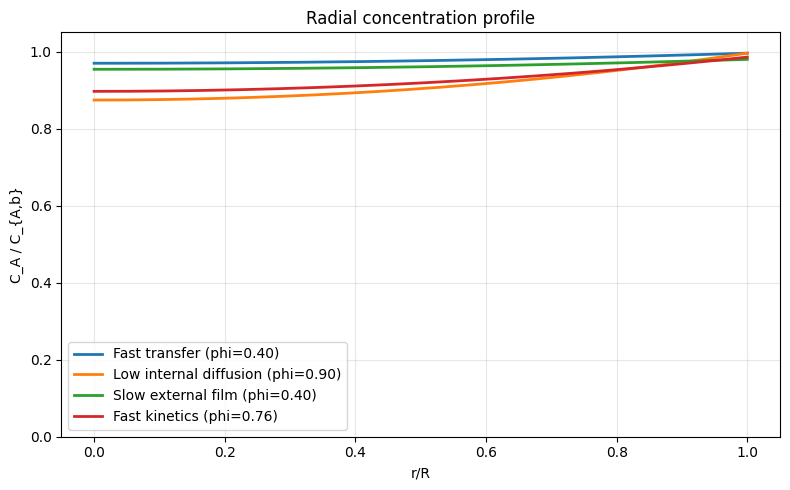

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
R_particle = 1.5e-3   # m
C_bulk = 1.0          # mol/L, used as reference
scenarios = [('Fast transfer', 0.03, 3.5e-06, 0.25), ('Low internal diffusion', 0.03, 7e-07, 0.25), ('Slow external film', 0.006, 3.5e-06, 0.25), ('Fast kinetics', 0.03, 3.5e-06, 0.9)]


def effectiveness_factor(phi):
    if phi < 1e-6:
        return 1.0
    return 3 / phi**2 * (phi / np.tanh(phi) - 1)


def profile(r_over_R, kf, De, k):
    phi = R_particle * np.sqrt(k / De)
    eta = effectiveness_factor(phi)
    C_surface = C_bulk / (1 + eta * k * R_particle / (3 * kf))
    r = np.maximum(r_over_R, 1e-6)
    internal = np.sinh(phi * r) / (r * np.sinh(phi)) if phi > 1e-6 else np.ones_like(r)
    internal[0] = phi / np.sinh(phi) if phi > 1e-6 else 1.0
    return C_surface * internal / C_bulk, phi, eta, C_surface / C_bulk

r = np.linspace(0, 1, 250)
plt.figure(figsize=(8, 5))
print("Scenario summary")
for name, kf, De, k in scenarios:
    C, phi, eta, Cs = profile(r, kf, De, k)
    plt.plot(r, C, linewidth=2, label=f"{name} (phi={phi:.2f})")
    print(f"{name}: phi={phi:.2f}, eta={eta:.2f}, C_surface/C_bulk={Cs:.2f}")

plt.xlabel("r/R")
plt.ylabel("C_A / C_{A,b}")
plt.title("Radial concentration profile")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation

If internal diffusion is slow or kinetics are fast, a strong gradient appears inside the particle. If external transfer is slow, even the surface concentration drops below the bulk-fluid concentration.
